## Data Cleaning

In [1]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import plotly.express as px
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
train_df = pd.read_csv(os.path.join('..', 'data', 'raw', 'train.csv'))
test_df = pd.read_csv(os.path.join('..', 'data', 'raw', 'test.csv'))

---
### Check for Duplicates

In [3]:
print(train_df.shape)

duplicated_rows = train_df[train_df.duplicated()].shape[0]
print('duplicated_rows =', duplicated_rows)

duplicated_rows = train_df[train_df.duplicated(subset=train_df.columns.difference(['Year']))].shape[0]
print('duplicated_rows (excluding date column) =', duplicated_rows)

(16165, 54)
duplicated_rows = 0
duplicated_rows (excluding date column) = 0


In [4]:
print(test_df.shape)

duplicated_rows = test_df[test_df.duplicated()].shape[0]
print('duplicated_rows =', duplicated_rows)

duplicated_rows = test_df[test_df.duplicated(subset=test_df.columns.difference(['Year']))].shape[0]
print('duplicated_rows (excluding date column) =', duplicated_rows)

(1060, 54)
duplicated_rows = 0
duplicated_rows (excluding date column) = 0


---
### View Missing Data

In [5]:
def plot_missing_by_indicator(df):
    value_cols = df.select_dtypes(include="number").columns
    value_cols = [c for c in value_cols if c not in ["Year"]]

    missing_by_year = (
        df
        .groupby("Year")[value_cols]
        .apply(lambda x: x.isna().sum())
    )

    # Transpose so indicators are on the left, years on the bottom
    missing_plot = missing_by_year.T

    plt.figure(figsize=(17,10))
    plt.imshow(missing_plot, aspect="auto", cmap="RdYlGn_r", vmax=275)
    plt.colorbar(label="Missing Count")
    plt.xticks(ticks=range(len(missing_plot.columns)), labels=missing_plot.columns, rotation=90)
    plt.yticks(ticks=range(len(missing_plot.index)), labels=missing_plot.index)
    plt.title("Missing Values By Indicator and Year")
    plt.tight_layout()
    plt.show()

In [6]:
def plot_missing_by_country(df):
    # pick indicator columns (exclude id-like columns)
    id_cols = ["Country Name", "Year"]
    indicator_cols = [c for c in df.columns if c not in id_cols]

    # count missing per row, then aggregate by country-year
    missing_counts = (
        df[indicator_cols]
        .isna()
        .sum(axis=1)
    )

    missing_by_country_year = (
        df[["Country Name", "Year"]]
        .assign(missing=missing_counts)
        .groupby(["Country Name", "Year"])["missing"]
        .sum()
        .unstack("Year")
        .sort_index()
    )

    # plot heatmap
    plt.figure(figsize=(18, 50))
    plt.imshow(missing_by_country_year, aspect="auto", cmap="RdYlGn_r", vmax=55)
    plt.colorbar(label="Missing Count")
    plt.xticks(
        ticks=range(len(missing_by_country_year.columns)),
        labels=missing_by_country_year.columns,
        rotation=90
    )
    plt.yticks(
        ticks=range(len(missing_by_country_year.index)),
        labels=missing_by_country_year.index
    )
    plt.title("Missing Values Per Year Per Country")
    plt.tight_layout()
    plt.show()

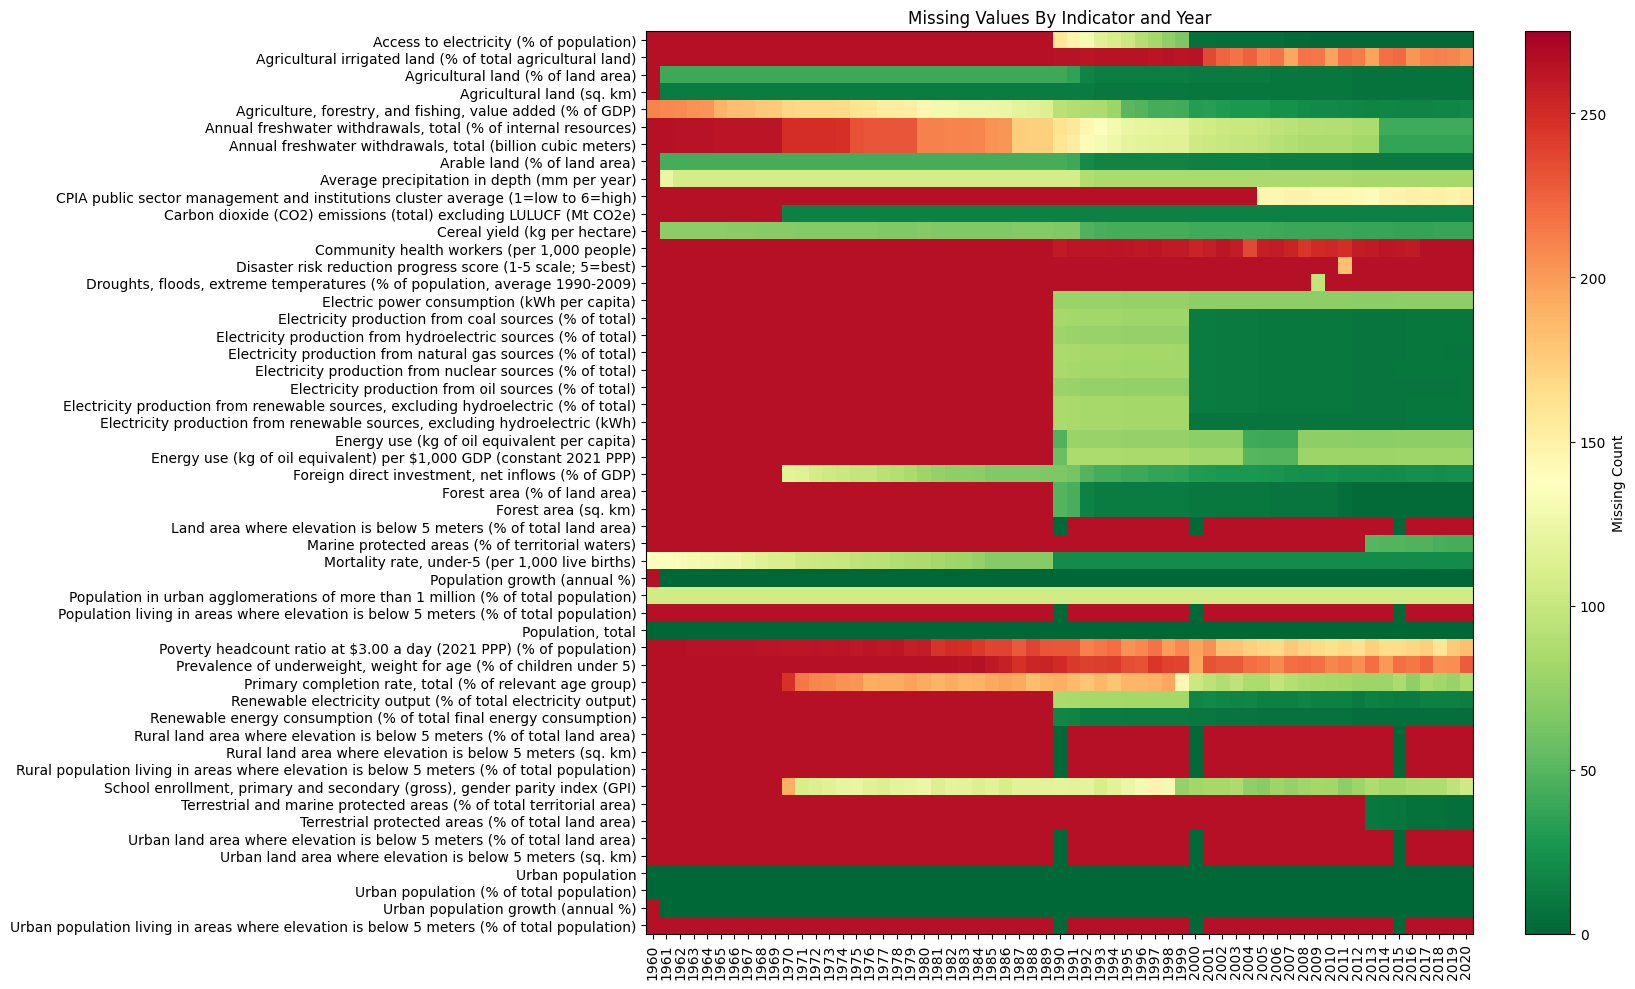

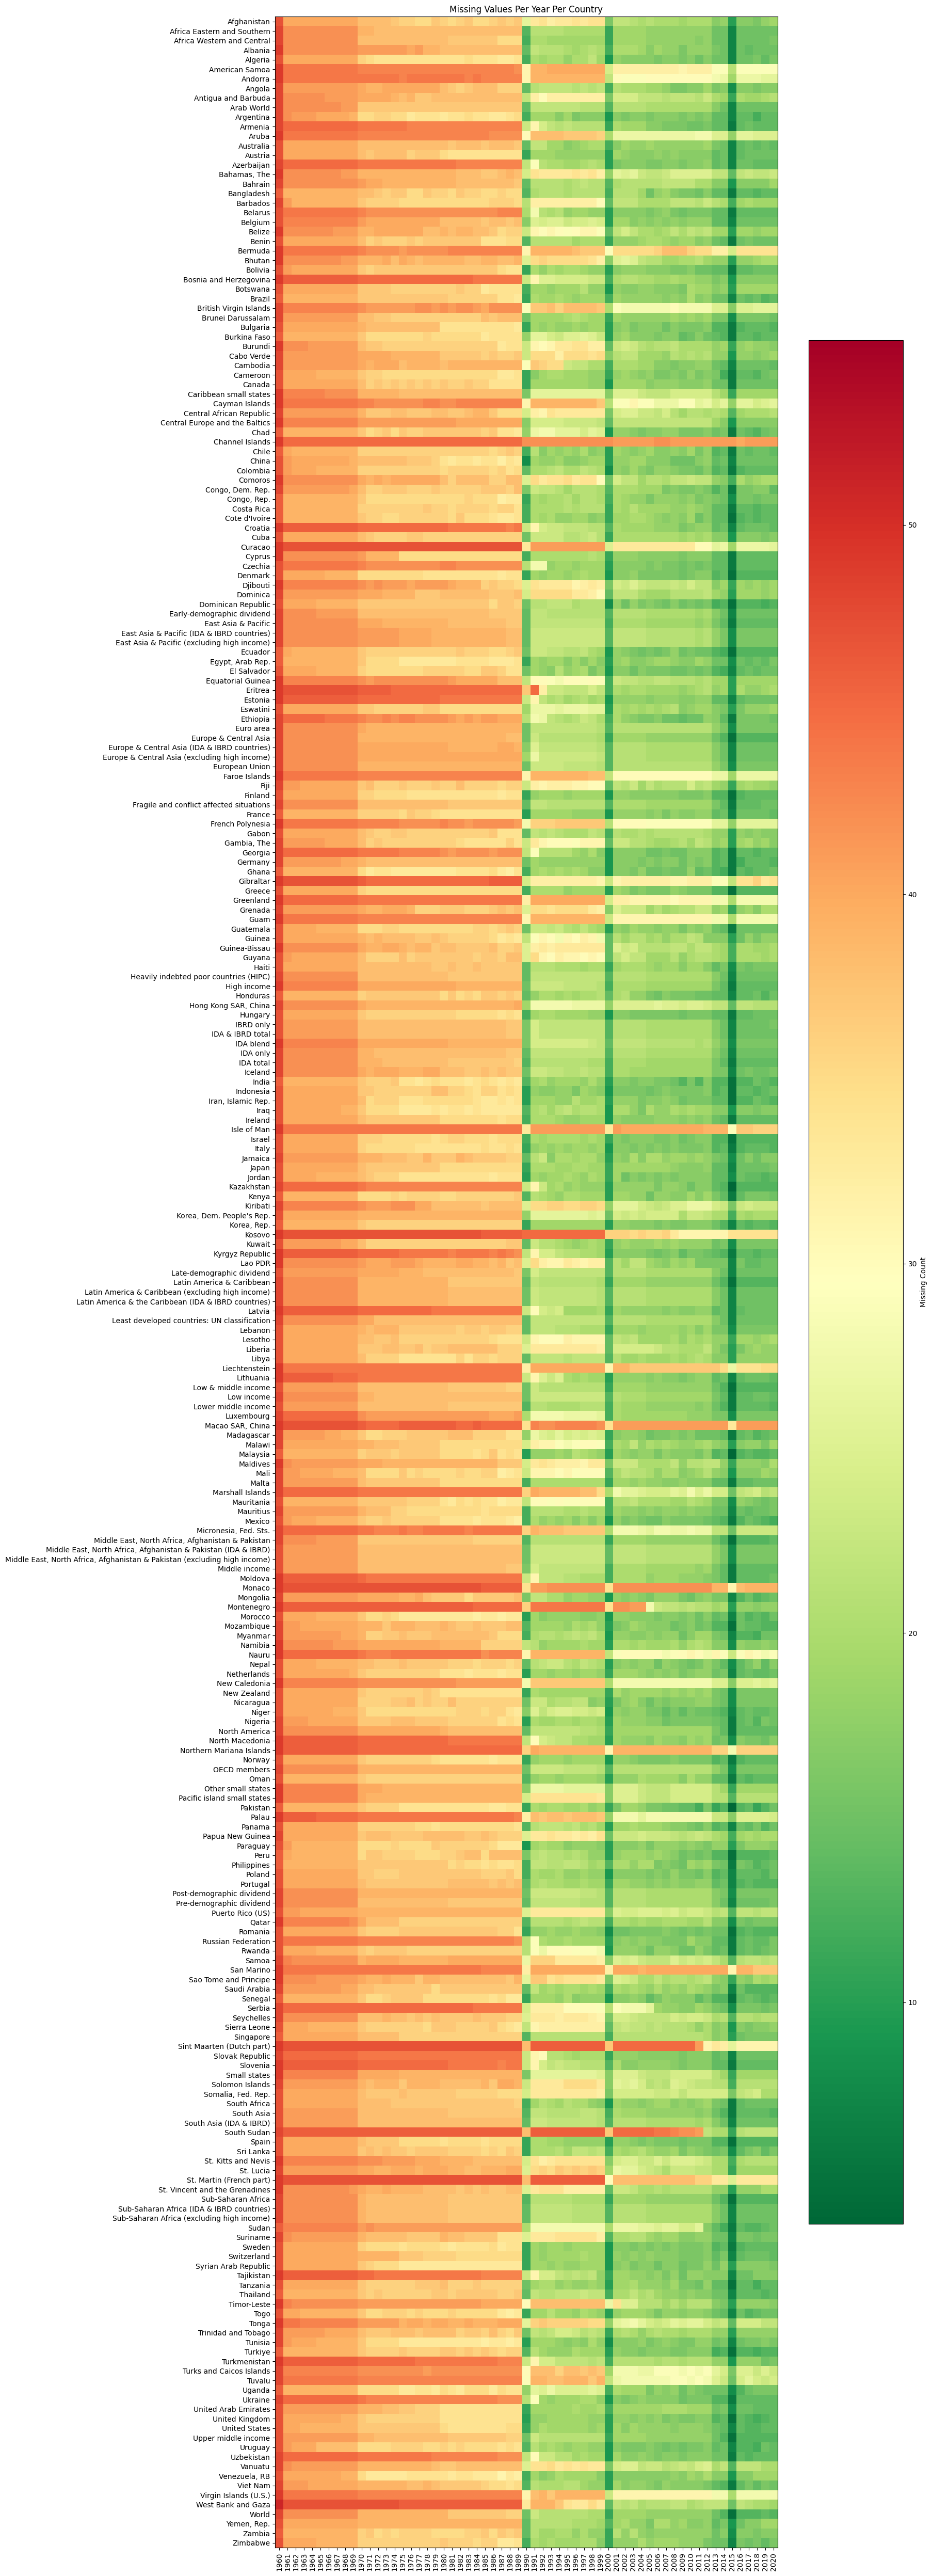

In [7]:
plot_missing_by_indicator(train_df)
plot_missing_by_country(train_df)

---
### Drop or Fill Missing Data

In [8]:
years_to_drop = range(1960, 1990)

train_df = train_df[~train_df['Year'].isin(years_to_drop)]

In [9]:
# Drop countries with more than 80% missing data
countries_to_drop = [
    "Sint Maarten (Dutch part)",
    "South Sudan",
    "St. Martin (French part)",
    "Monaco",
    "Kosovo",
    "Macao SAR, China",
    "Channel Islands",
    "Montenegro",
    "Curacao",
    "Northern Mariana Islands",
    "Isle of Man",
    "San Marino",
    "Liechtenstein"
]

train_df = train_df[~train_df['Country Name'].isin(countries_to_drop)]

In [10]:
# Drop indicators with more than 80% missing data
indicators_to_drop = [
    "Disaster risk reduction progress score (1-5 scale; 5=best)", 
    "Droughts, floods, extreme temperatures (% of population, average 1990-2009)", 
    "Marine protected areas (% of territorial waters)", 
    "Terrestrial and marine protected areas (% of total territorial area)", 
    "Terrestrial protected areas (% of total land area)", 
    "Community health workers (per 1,000 people)",
    "Agricultural irrigated land (% of total agricultural land)",
    "CPIA public sector management and institutions cluster average (1=low to 6=high)",
    "Land area where elevation is below 5 meters (% of total land area)",
    "Population living in areas where elevation is below 5 meters (% of total population)",
    "Rural land area where elevation is below 5 meters (% of total land area)",
    "Rural land area where elevation is below 5 meters (sq. km)",
    "Rural population living in areas where elevation is below 5 meters (% of total population)",
    "Urban land area where elevation is below 5 meters (% of total land area)",
    "Urban land area where elevation is below 5 meters (sq. km)",
    "Urban population living in areas where elevation is below 5 meters (% of total population)",
    "Prevalence of underweight, weight for age (% of children under 5)",
    "Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)"
]

train_df = train_df.drop(columns=indicators_to_drop)

In [11]:
# Linearly interpolate missing data where possible

train_df["Year"] = pd.to_numeric(train_df["Year"], errors="coerce")
train_df = train_df.sort_values(["Country Name", "Year"])

num_cols = train_df.select_dtypes(include="number").columns

train_df[num_cols] = (
    train_df.groupby("Country Name", group_keys=False)[num_cols]
      .apply(lambda g: g.interpolate(method="linear", limit_direction="both"))
)

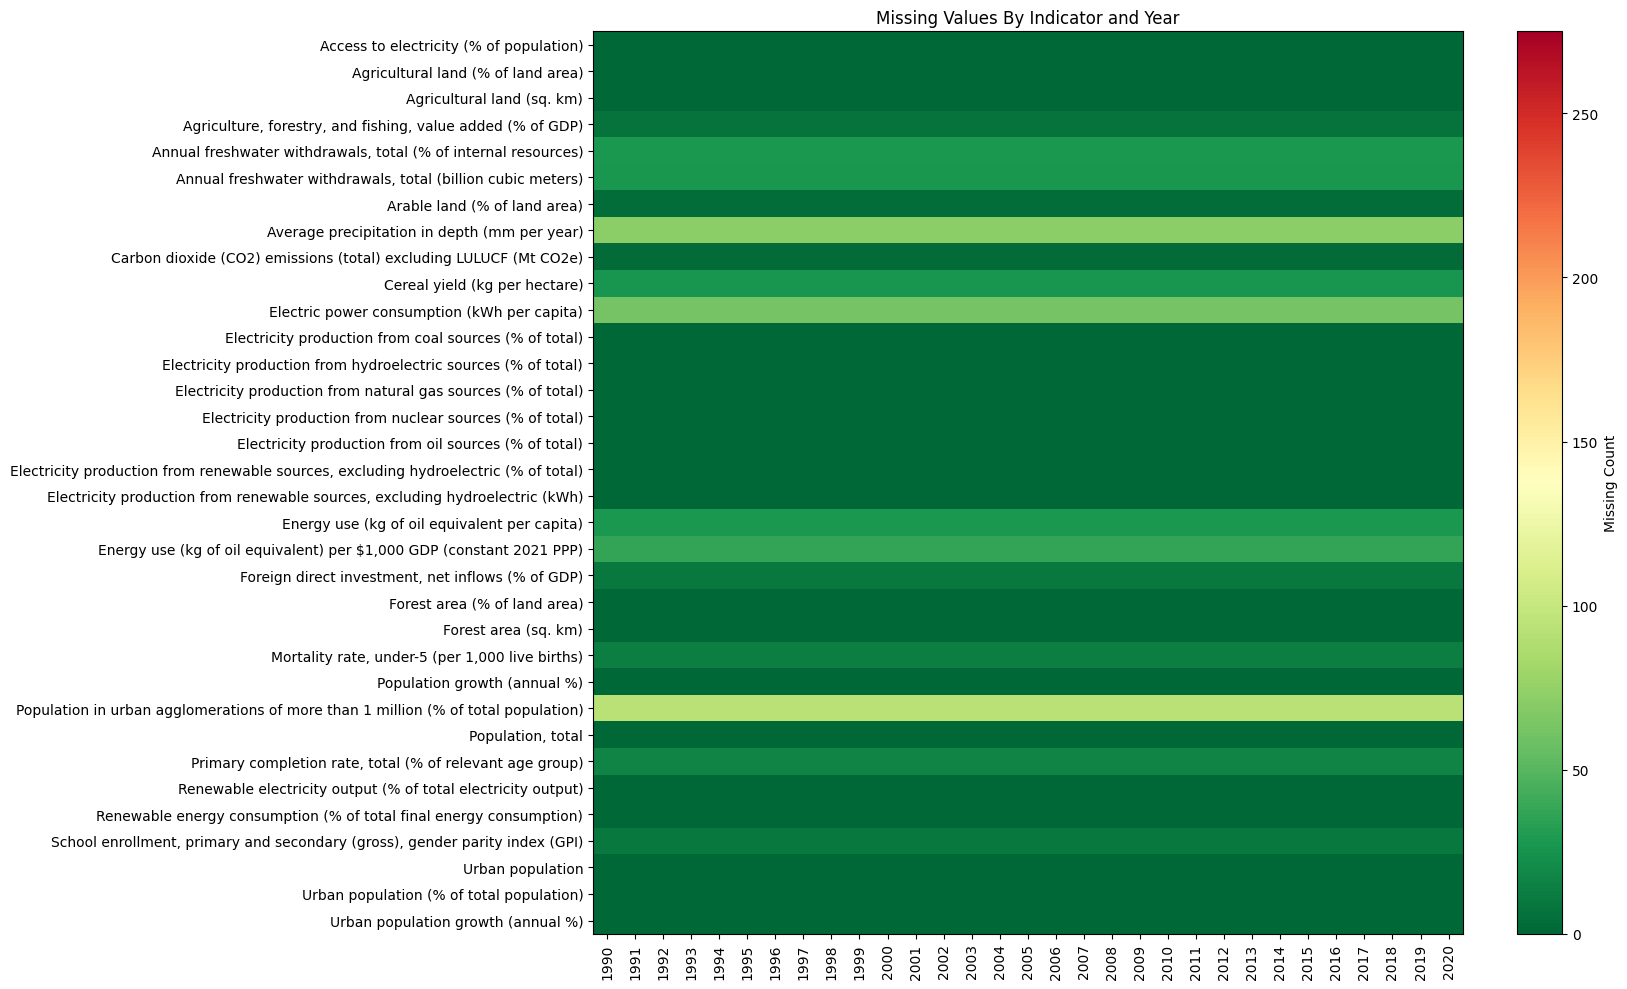

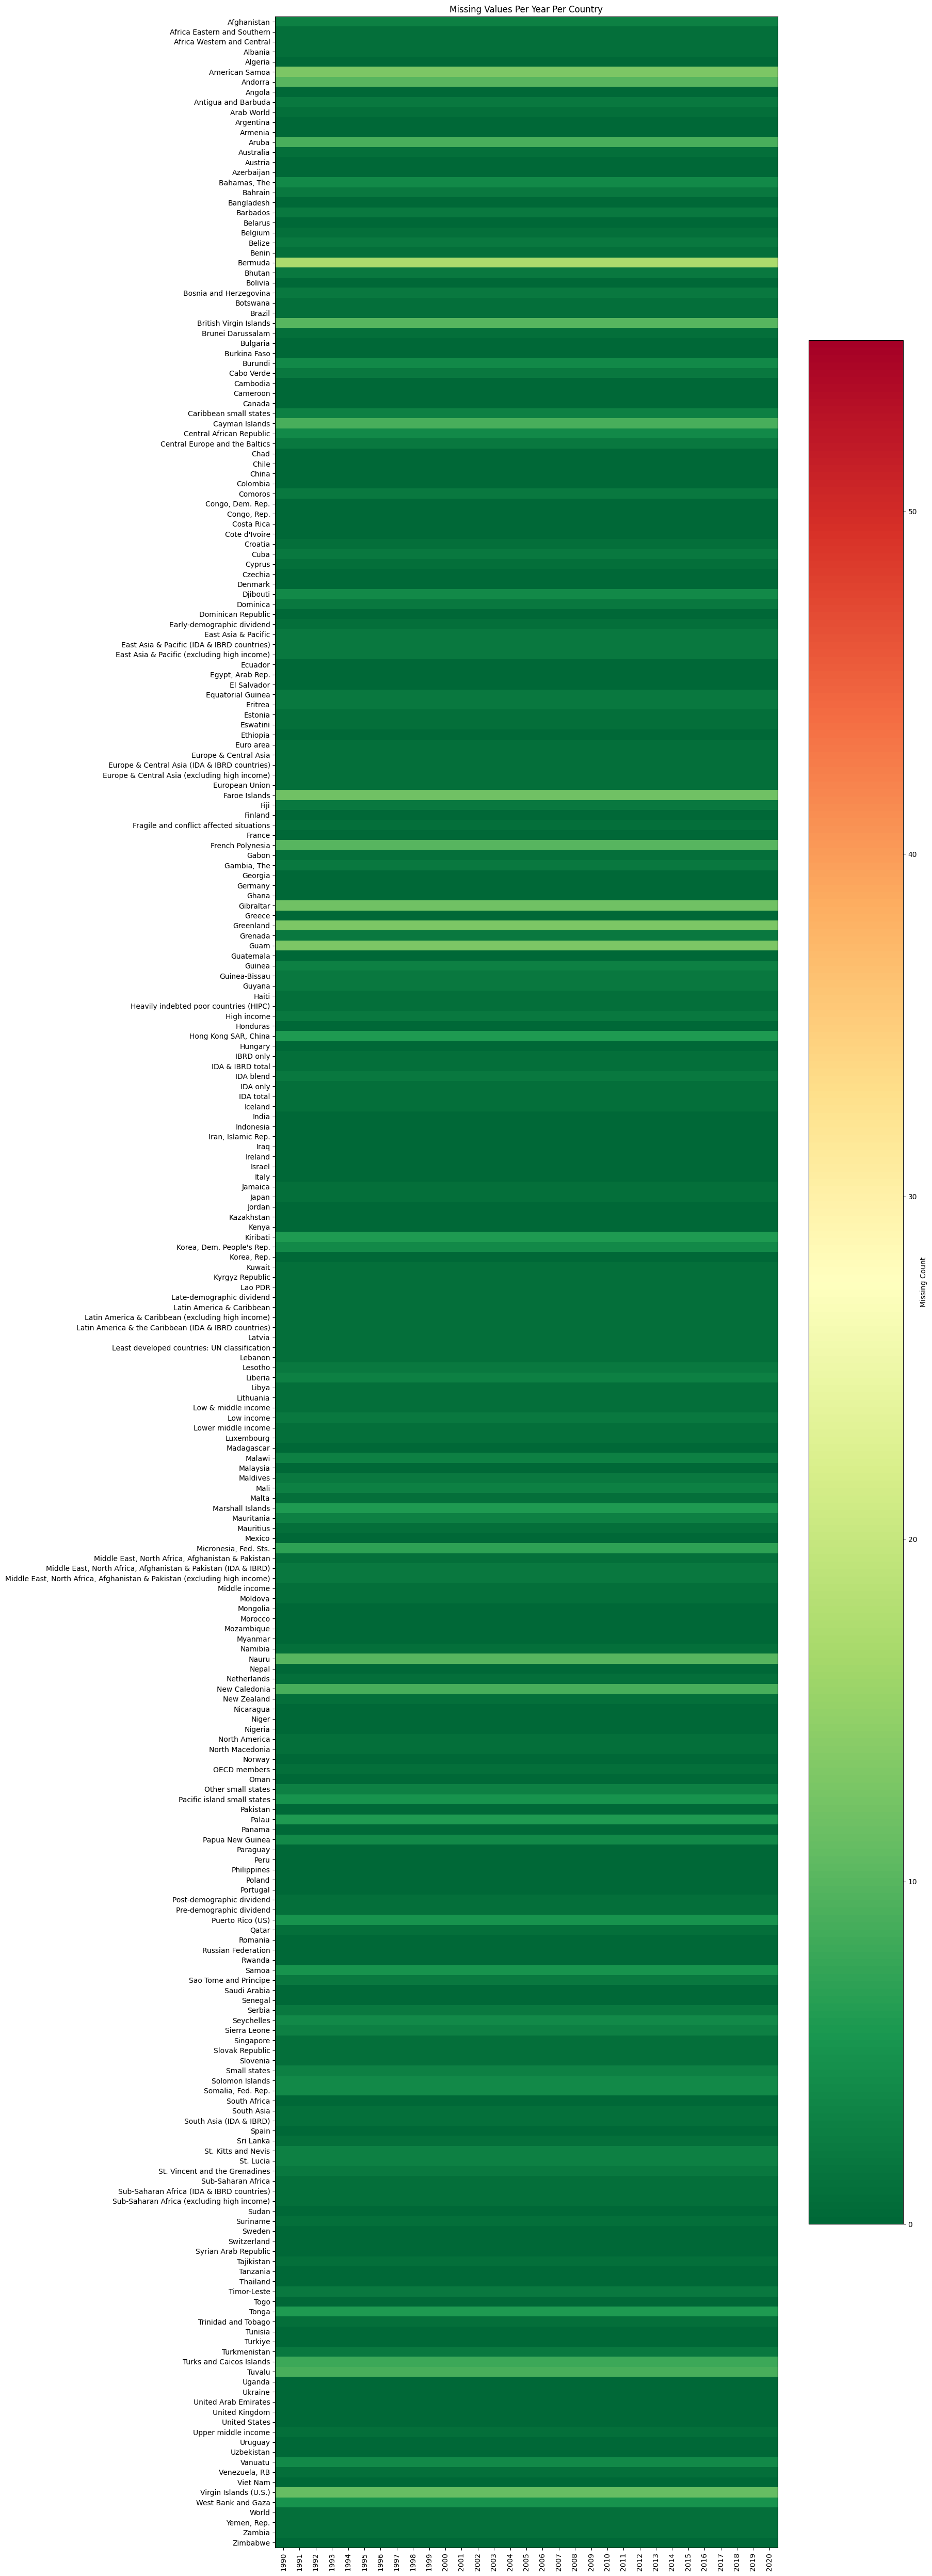

In [12]:
plot_missing_by_indicator(train_df)
plot_missing_by_country(train_df)

In [15]:
# Fill remaining missing data with zeros
train_df = train_df.fillna(0)

In [ ]:
# Apply same clean to test_df

test_df = test_df[~test_df['Year'].isin(years_to_drop)]
test_df = test_df[~test_df['Country Name'].isin(countries_to_drop)]
test_df = test_df.drop(columns=indicators_to_drop)
test_df["Year"] = pd.to_numeric(test_df["Year"], errors="coerce")
test_df = test_df.sort_values(["Country Name", "Year"])
num_cols = test_df.select_dtypes(include="number").columns
test_df[num_cols] = (
    test_df.groupby("Country Name", group_keys=False)[num_cols]
      .apply(lambda g: g.interpolate(method="linear", limit_direction="both"))
)
test_df = test_df.fillna(0)

In [ ]:
train_df.to_csv(os.path.join('..', 'data', 'processed', 'train_cleaned.csv'), index=False)
test_df.to_csv(os.path.join('..', 'data', 'processed', 'test_cleaned.csv'), index=False)

---
## Data Exploration

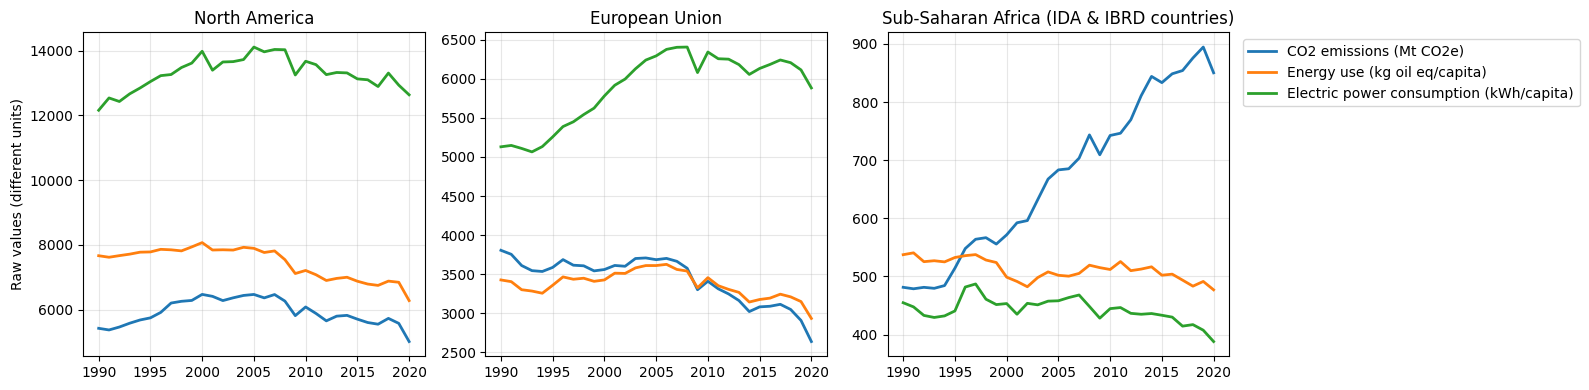

In [ ]:

regions = ["North America", "European Union", "Sub-Saharan Africa (IDA & IBRD countries)"]
cols = {
    "CO2 emissions (Mt CO2e)": "Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)",
    "Energy use (kg oil eq/capita)": "Energy use (kg of oil equivalent per capita)",
    "Electric power consumption (kWh/capita)": "Electric power consumption (kWh per capita)",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

for ax, country in zip(axes, regions):
    one = train_df[train_df["Country Name"] == country].sort_values("Year")

    for label, col in cols.items():
        ax.plot(one["Year"], one[col], label=label, linewidth=2)

    ax.set_title(country)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Raw values (different units)")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [16]:
# Multicolinearity

def calculate_vif(df, target_col=None):
    # Keep only numeric columns
    numeric_df = df.select_dtypes(include=['number']).copy()

    # Drop target if provided
    if target_col and target_col in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=[target_col])

    # Add constant for statsmodels
    X = add_constant(numeric_df)

    # Compute VIF (skip the first column = constant)
    vif_data = pd.DataFrame()
    vif_data["feature"] = numeric_df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i + 1)  # skip constant at index 0
        for i in range(len(numeric_df.columns))
    ]

    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

vif_table = calculate_vif(train_df, target_col="Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)")
print(vif_table)

                                              feature        VIF
0                                   Population, total  78.648568
1                                    Urban population  64.442936
2   Renewable electricity output (% of total elect...  52.173677
3                          Agricultural land (sq. km)  47.658490
4   Electricity production from hydroelectric sour...  46.909881
5   Annual freshwater withdrawals, total (billion ...  32.506808
6   Electricity production from oil sources (% of ...  24.251150
7                                Forest area (sq. km)  21.993646
8   Electricity production from natural gas source...  13.006880
9   Electricity production from coal sources (% of...  12.123751
10  Renewable energy consumption (% of total final...   6.165703
11       Energy use (kg of oil equivalent per capita)   5.917484
12            Access to electricity (% of population)   5.453073
13    Mortality rate, under-5 (per 1,000 live births)   4.976876
14        Electric power 

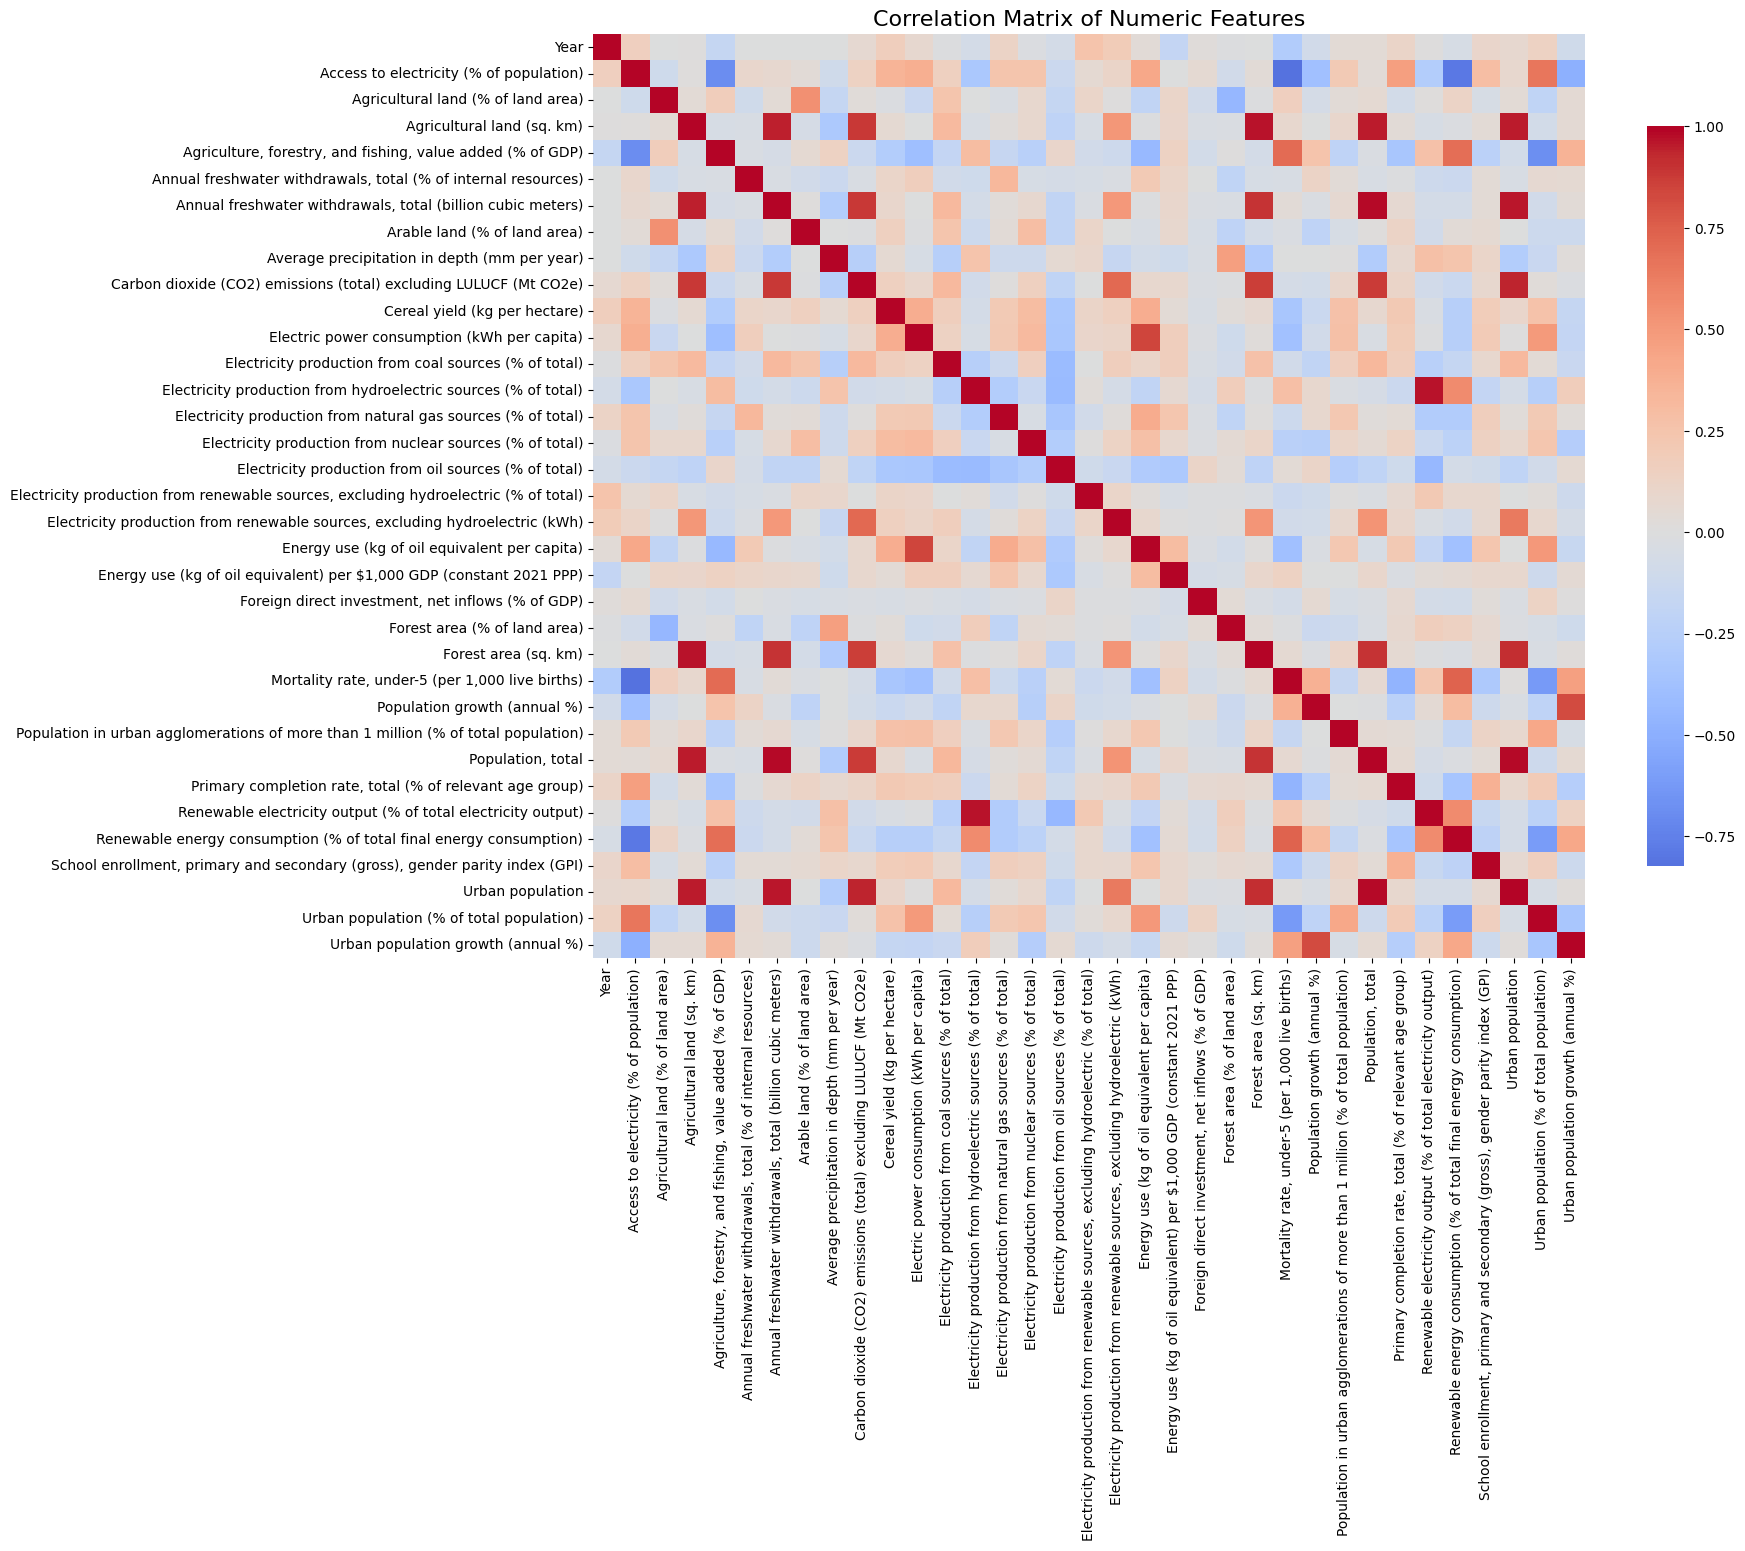

In [17]:
# Select only numeric features (exclude the target 'price')
numeric_df = train_df.select_dtypes(include=['number']).drop(columns=["price"], errors="ignore")

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Display full matrix as heatmap
plt.figure(figsize=(16,12))
sns.heatmap(
    corr_matrix, 
    cmap="coolwarm", 
    center=0, 
    annot=False,   # set to True if you want numbers on cells
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Numeric Features", fontsize=16)
plt.show()

/var/folders/kx/6sl1xcms7v51c6b6wsvk2dj00000gn/T/ipykernel_33235/1234627829.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


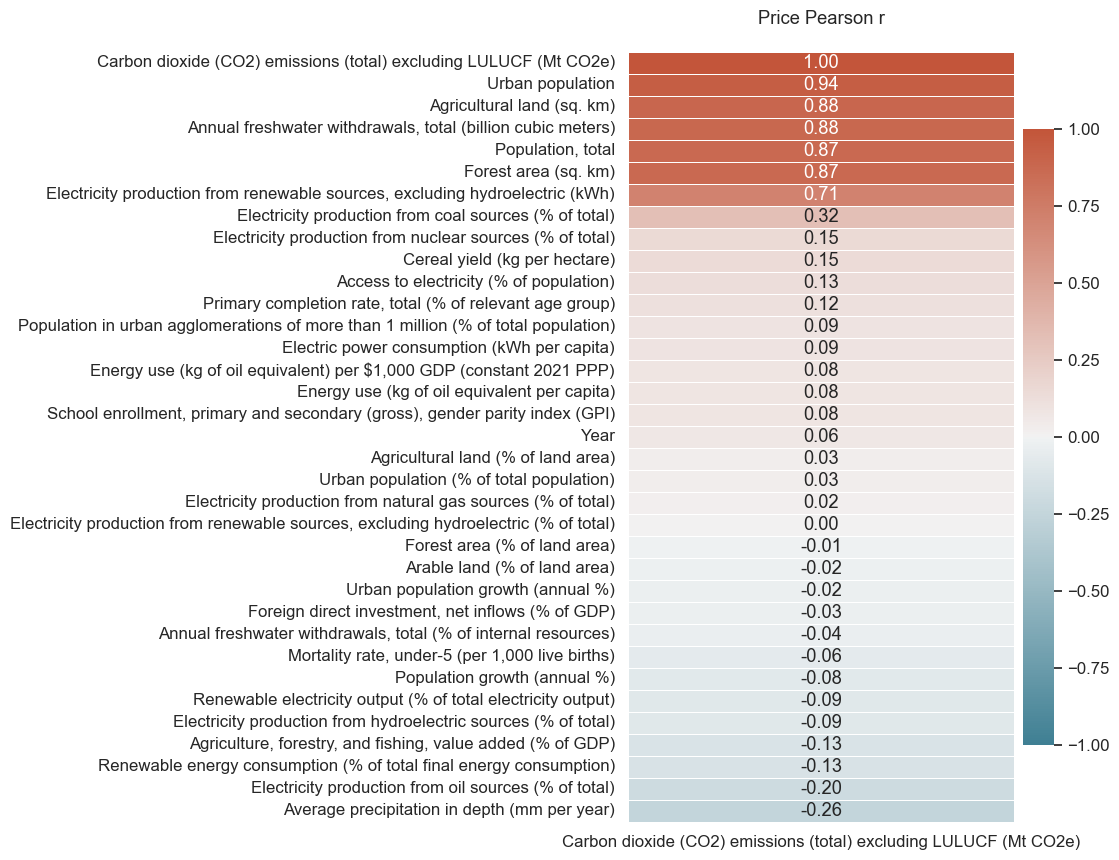

In [19]:
num_cols = train_df.select_dtypes("number").columns
corr_vec  = train_df[num_cols].corr(method="pearson")["Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)"].sort_values(ascending=False)
sns.set_theme(style="white")     
sns.set(font_scale=1.1)          
plt.figure(figsize=(6,10))       
ax = sns.heatmap(
        corr_vec.to_frame(),     
        annot=True, fmt=".2f",
        vmin=-1, vmax=1,         
        cmap=sns.diverging_palette(220, 20, as_cmap=True),
        center=0,
        linewidths=.5, linecolor="white",
        cbar_kws={"shrink":0.8, "pad":0.02}
     )
ax.set_title("Price Pearson r", pad=20)
ax.set_ylabel("")                 
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [ ]:
cols = {
    "co2": "Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)",
    "energy_use_pc": "Energy use (kg of oil equivalent per capita)",
    "electric_pc": "Electric power consumption (kWh per capita)",
    "coal_pct": "Electricity production from coal sources (% of total)",
    "renewable_pct": "Renewable electricity output (% of total electricity output)",
}

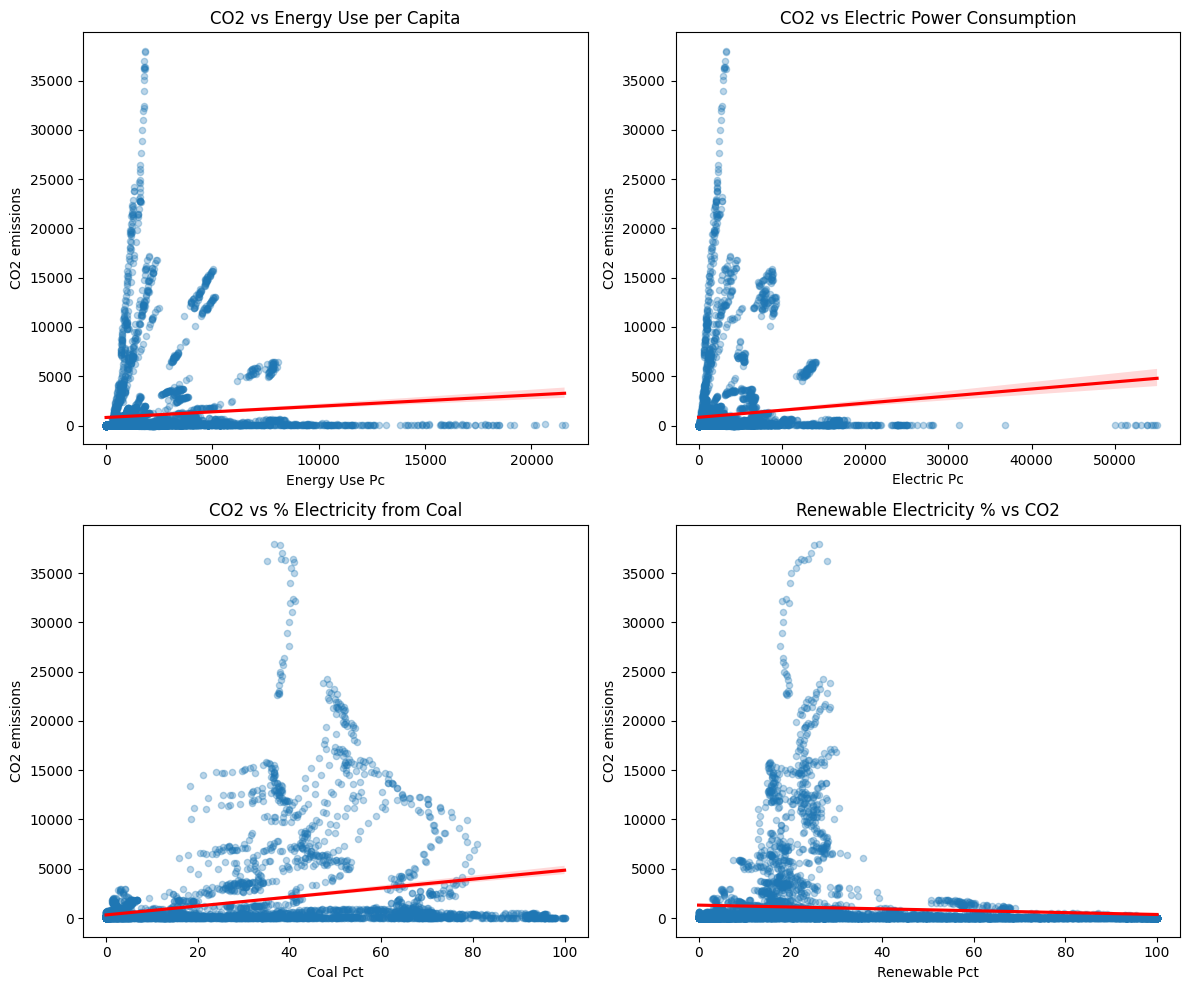

In [ ]:
scatter_pairs = [
    ("energy_use_pc", "co2", "CO2 vs Energy Use per Capita"),
    ("electric_pc", "co2", "CO2 vs Electric Power Consumption"),
    ("coal_pct", "co2", "CO2 vs % Electricity from Coal"),
    ("renewable_pct", "co2", "Renewable Electricity % vs CO2"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (xkey, ykey, title) in zip(axes, scatter_pairs):
    sns.regplot(
        data=train_df,
        x=cols[xkey],
        y=cols[ykey],
        scatter_kws={"alpha": 0.3, "s": 20},
        line_kws={"color": "red"},
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel(xkey.replace("_", " ").title())
    ax.set_ylabel("CO2 emissions")

plt.tight_layout()
plt.show()

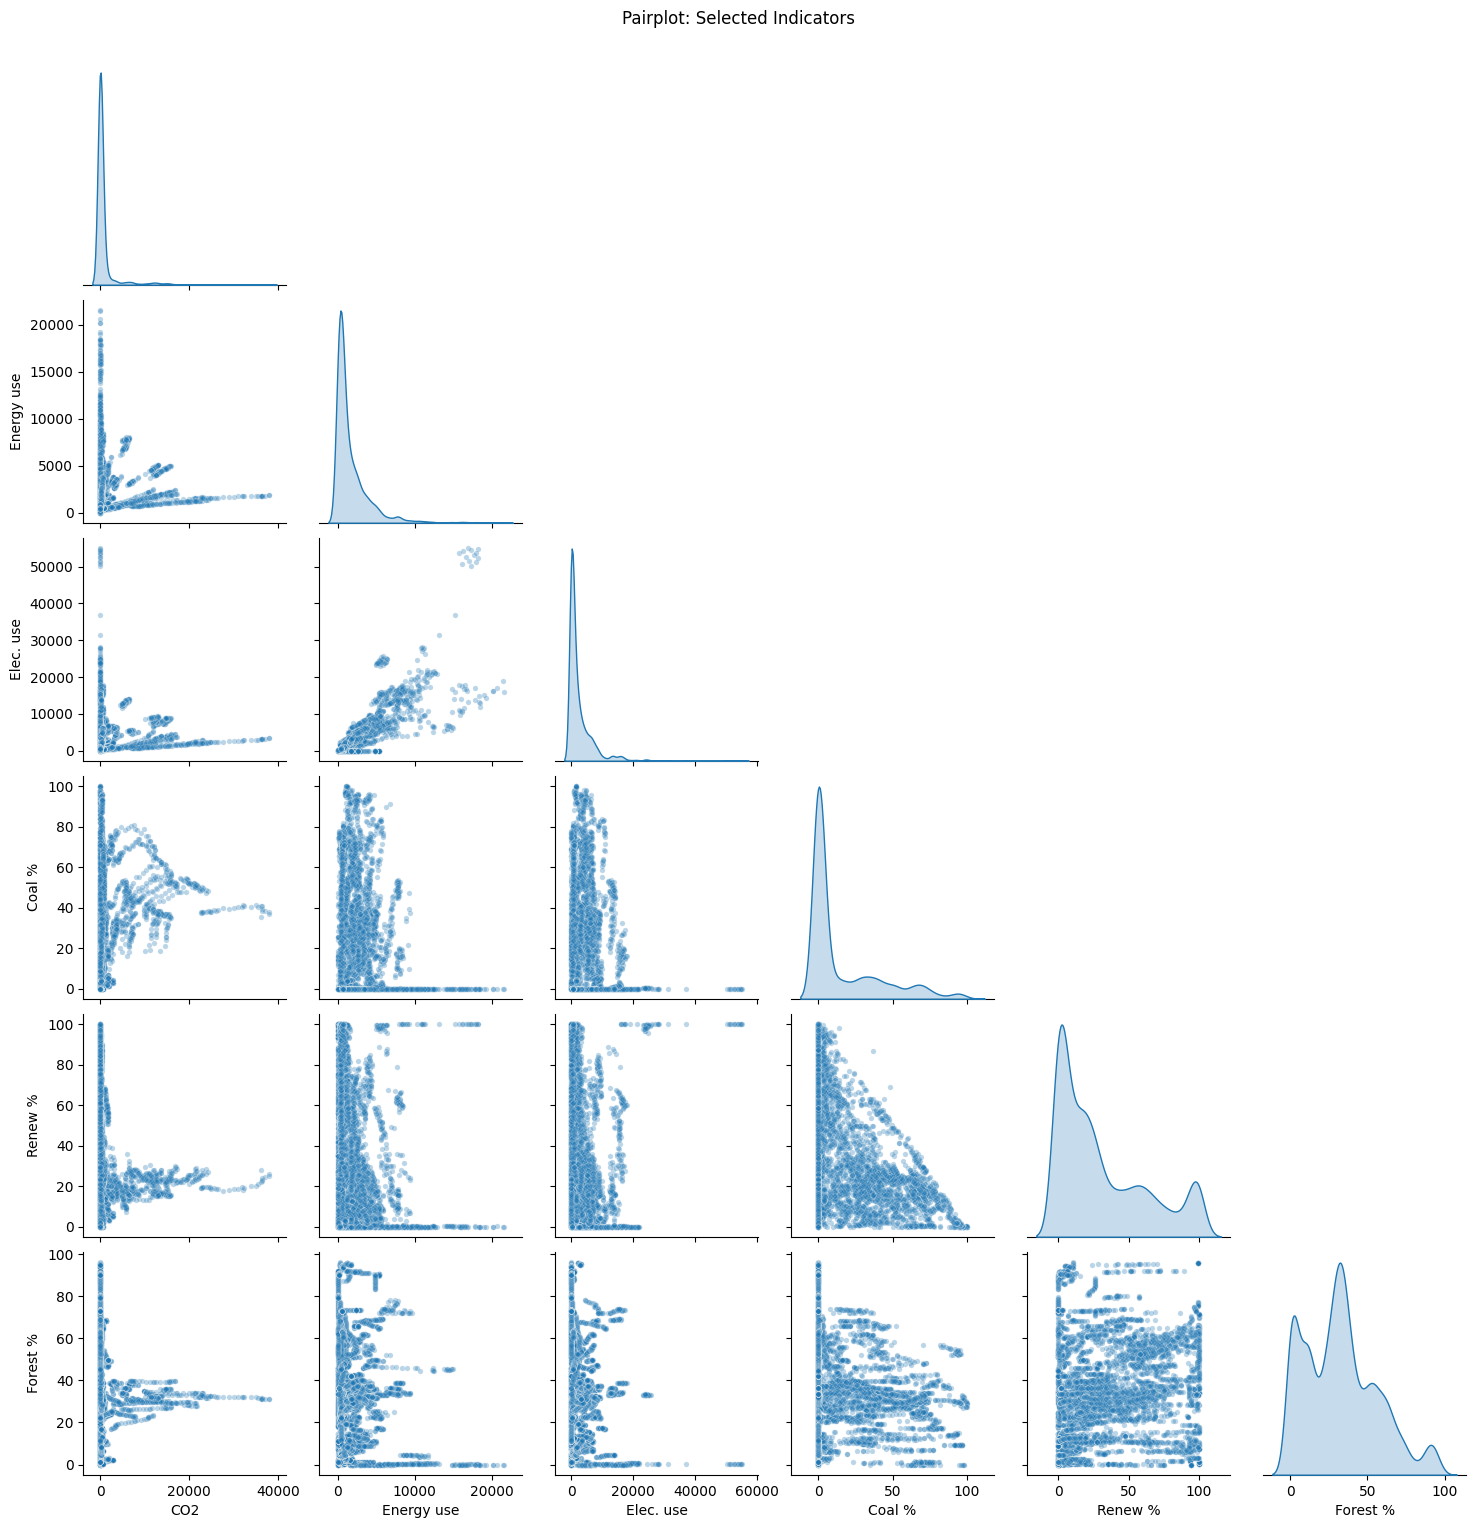

In [ ]:
short_cols = {
    cols["co2"]: "CO2",
    cols["energy_use_pc"]: "Energy use",
    cols["electric_pc"]: "Elec. use",
    cols["coal_pct"]: "Coal %",
    cols["renewable_pct"]: "Renew %",
    "Forest area (% of land area)": "Forest %"
}

pair_df = train_df[short_cols.keys()].rename(columns=short_cols).dropna()

sns.pairplot(pair_df, diag_kind="kde", corner=True, plot_kws={"alpha": 0.3, "s": 15})
plt.suptitle("Pairplot: Selected Indicators", y=1.02)
plt.show()